In [1]:
# 7-9-2026

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors

,domain_id,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
0,0,11.229313,5.895861,19.746270,2.516127,1.052111,3.968697,302.43317,4.790887,307.46002,...,0.479085,547.384100,1932.25460,1112.033700,0.067789,0.469590,0.097816,0.081824,0.728328,6
1,1,6.742952,3.144529,10.522034,1.406203,0.511182,2.132592,301.80650,4.735351,305.51370,...,0.499585,338.661650,1157.09030,705.891970,0.063071,0.392797,0.108795,0.013560,0.218936,7
2,2,21.599873,10.565010,36.654785,4.066474,0.951055,5.291819,303.89624,6.380806,311.61792,...,0.257699,3360.493400,8181.07230,8625.163000,0.162555,0.925012,0.219152,0.032987,0.602900,7
3,3,4.211150,2.716757,7.958644,3.166607,1.505368,5.099028,286.08792,10.954839,299.41890,...,0.411259,328.766850,739.65440,901.446350,0.041860,0.274789,0.000000,0.001419,0.365885,3
4,4,2.564834,3.033652,6.938553,3.300411,1.380530,5.114551,273.42078,16.251247,293.80110,...,0.447848,669.052060,2307.77000,1315.654900,0.185203,1.571907,0.090595,0.007227,0.615066,5
5,5,10.265495,5.699432,17.502420,2.046542,0.978449,3.276847,301.65985,5.860431,307.49870,...,0.491258,615.784000,2284.54270,1215.513500,0.141646,0.628370,0.270441,0.058533,0.560294,4
6,6,3.370416,3.105505,7.804835,3.172674,1.288420,4.654522,280.81445,12.255744,296.83127,...,0.394887,558.122500,2520.26320,715.896240,0.287090,2.909752,0.000000,0.003038,0.626834,4
7,7,11.621094,8.784235,24.302675,3.065614,1.245384,4.709380,295.90033,8.041678,307.00922,...,0.286967,513.446900,1531.67580,1095.658200,0.117847,0.972292,0.076211,0.004830,0.655366,3
8,8,7.512378,2.146205,10.056996,1.712309,1.128670,3.099993,302.63660,2.228121,305.12260,...,0.488031,328.441350,895.73500,747.977050,0.100920,0.937725,0.149864,0.019789,0.553258,5
9,9,3.658946,1.855246,6.112502,3.419243,1.666298,5.511101,287.73157,4.825871,294.05838,...,0.401618,1132.007300,4253.38570,1966.245800,0.543724,5.499713,0.000000,0.002421,0.625943,2


In [4]:
embeddings = pd.read_csv("domain_embeddings_v3.csv")
embeddings

,domain_id,e_0,e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8
0,0,-0.282419,0.071347,-0.358681,0.052459,-0.092510,-0.545185,0.104237,-0.302652,0.208815
1,1,-0.497810,0.043205,-0.766936,-0.029026,-0.783881,-0.543932,-0.130131,0.010463,0.017025
2,2,-0.215404,0.159873,-0.081520,-0.159898,0.172823,-0.091057,-0.272607,-0.289642,0.055114
3,4,-0.007080,0.258019,-0.115532,-0.157424,0.567847,-0.834059,0.085684,-0.189975,0.182037
4,5,-0.214624,-0.017152,-0.241061,-0.144824,-0.180719,-0.442516,0.157234,-0.367527,0.445947
5,6,-0.109571,0.317965,-0.192132,-0.210169,0.516822,-0.650644,0.147307,-0.249578,0.148294
6,7,-0.133822,0.221077,-0.038859,-0.235565,0.019519,-0.019816,0.089963,-0.154965,0.127107
7,8,-0.424860,-0.079106,-0.915420,-0.230660,-0.459639,-0.250796,0.052310,-0.178515,0.057711
8,11,-0.381096,0.098376,-0.329350,-0.270441,-0.005636,-0.120294,0.310009,-1.090684,0.452384
9,12,-0.488668,-0.821297,0.109583,-0.397317,0.192787,-0.156481,-0.017964,-0.137933,0.190920


In [6]:
# corr matrix between embedding dims and raw descriptors
merged_full = embeddings.merge(descriptors, on="domain_id", how="inner")

emb_cols = [c for c in embeddings.columns if c.startswith("e_")]
desc_cols = [c for c in descriptors.columns if c != "domain_id"]

corr_matrix = merged_full[emb_cols + desc_cols].corr(method="spearman").loc[emb_cols, desc_cols]
corr_matrix

,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,ndvi_mean,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
e_0,-0.513827,-0.146524,-0.327731,0.235141,0.363789,0.293506,-0.851490,0.840794,-0.529106,-0.350038,...,-0.041711,-0.222307,-0.151413,-0.317036,-0.155080,0.236975,-0.657340,-0.502215,0.279450,-0.007219
e_1,-0.584416,-0.444156,-0.529717,0.260504,0.286478,0.277617,-0.739343,0.522078,-0.606112,-0.063407,...,0.029794,-0.123300,-0.070435,-0.216196,0.000153,0.277005,-0.411621,-0.312147,0.599083,-0.002040
e_2,0.251642,0.620474,0.463102,0.307257,0.112911,0.284034,-0.189916,0.564859,0.229030,-0.619557,...,-0.410848,0.217723,0.287395,0.164248,0.062796,0.152330,-0.283639,-0.344538,-0.157830,-0.142494
e_3,-0.493659,-0.502521,-0.508021,-0.241864,-0.197861,-0.231780,-0.261115,0.104049,-0.380901,0.407792,...,0.286173,-0.496715,-0.494576,-0.515050,-0.409626,-0.249198,-0.215902,0.060963,0.200917,0.254856
e_4,-0.184110,-0.041406,-0.112911,0.300229,0.215584,0.275477,-0.335371,0.342399,-0.227502,-0.155080,...,-0.254087,0.077464,0.115661,0.035600,-0.088770,-0.027044,-0.219725,-0.016960,0.473186,0.015693
e_5,0.734454,0.650420,0.711841,0.332315,0.131245,0.284034,0.401375,-0.251948,0.605500,-0.405042,...,-0.804125,0.205500,0.179526,0.261727,-0.064324,-0.083881,0.046024,0.096715,0.013598,0.153008
e_6,0.108938,0.051490,0.082659,-0.009626,-0.065546,-0.018182,0.111688,-0.175554,0.043850,0.013293,...,0.134912,0.571887,0.548663,0.551413,0.733231,0.475630,0.441132,0.215279,0.142246,-0.506888
e_7,-0.145913,-0.038655,-0.110160,-0.018793,0.215584,0.040794,-0.230863,0.253782,-0.073491,-0.050879,...,-0.128189,-0.647670,-0.609167,-0.647059,-0.736287,-0.379985,-0.642661,-0.438044,-0.101910,0.507986
e_8,0.275783,0.223529,0.247059,0.085409,-0.129717,0.055157,0.264782,-0.221390,0.229641,-0.082659,...,0.068602,0.763178,0.753705,0.738121,0.678228,0.465546,0.523548,0.203361,0.034377,-0.298797


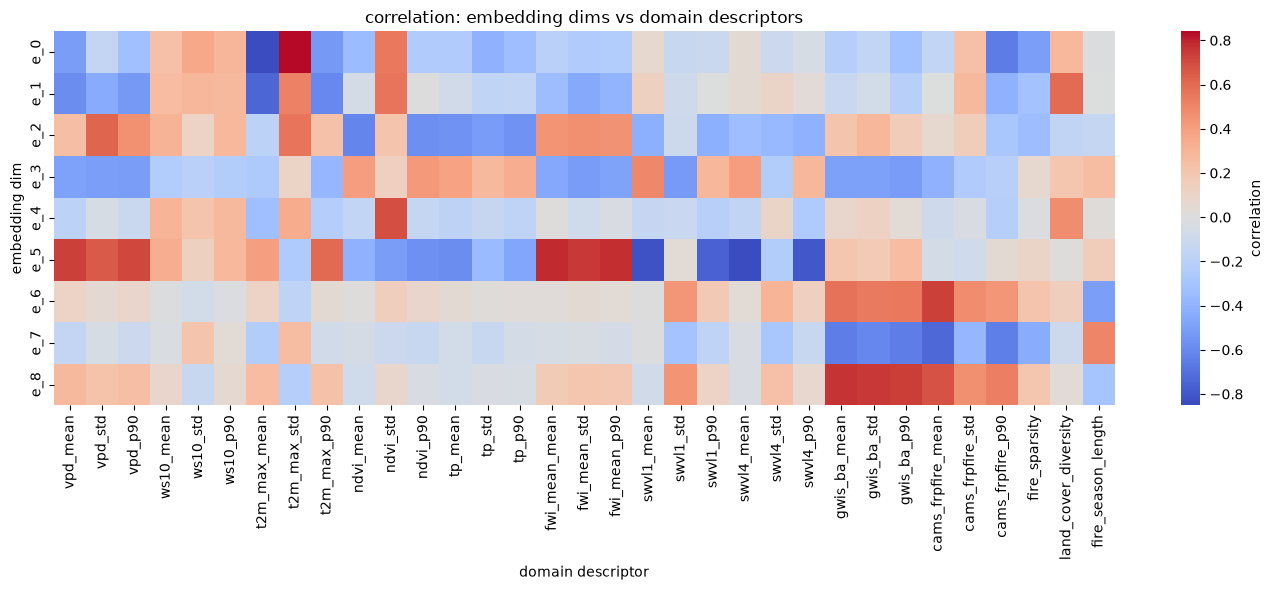

In [7]:
plt.figure(figsize=(14, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, cbar_kws={"label": "correlation"})
plt.xlabel("domain descriptor")
plt.ylabel("embedding dim")
plt.title("correlation: embedding dims vs domain descriptors")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [8]:
avg_abs_corr = corr_matrix.abs().mean(axis=1).sort_values(ascending=False)
avg_abs_corr

e_5    0.421843
e_3    0.347210
e_2    0.342802
e_0    0.302107
e_1    0.269159
e_8    0.243884
e_7    0.225775
e_6    0.193716
e_4    0.172520
dtype: float64

In [9]:
atmospheric_cols = ["vpd_mean", "vpd_std", "vpd_p90", "ws10_mean", "ws10_std", "ws10_p90",
                     "t2m_max_mean", "t2m_max_std", "t2m_max_p90", "tp_mean", "tp_std", "tp_p90"]

ground_cols = ["ndvi_mean", "ndvi_std", "ndvi_p90", "swvl1_mean", "swvl1_std", "swvl1_p90",
               "swvl4_mean", "swvl4_std", "swvl4_p90", "land_cover_diversity"]

fire_cols = ["fwi_mean_mean", "fwi_mean_std", "fwi_mean_p90", "gwis_ba_mean", "gwis_ba_std", "gwis_ba_p90",
             "cams_frpfire_mean", "cams_frpfire_std", "cams_frpfire_p90", "fire_sparsity", "fire_season_length"]


In [11]:
branch_cols = {
    "atmospheric": atmospheric_cols,
    "ground": ground_cols,
    "fire": fire_cols
}

# adjust this if your concat order or dims-per-branch differs
dim_to_branch = {
    "e_0": "atmospheric", "e_1": "atmospheric", "e_2": "atmospheric",
    "e_3": "ground", "e_4": "ground", "e_5": "ground",
    "e_6": "fire", "e_7": "fire", "e_8": "fire"
}

In [ ]:
rows = []
for dim, own_branch in dim_to_branch.items():
    own_cols = branch_cols[own_branch]
    other_cols = [c for c in corr_matrix.columns if c not in own_cols]

    within = corr_matrix.loc[dim, own_cols].abs().mean()
    outside = corr_matrix.loc[dim, other_cols].abs().mean()

    rows.append({"dim": dim, "branch": own_branch, "within": within, "outside": outside, "gap": within - outside})

separation_df = pd.DataFrame(rows).sort_values("gap", ascending=False)
separation_df

,dim,branch,within,outside,gap
8,e_8,fire,0.453910,0.138871,0.315039
7,e_7,fire,0.431252,0.123036,0.308216
6,e_6,fire,0.377162,0.101993,0.275169
0,e_0,atmospheric,0.425439,0.231631,0.193808
1,e_1,atmospheric,0.387319,0.201640,0.185679
5,e_5,ground,0.499862,0.387921,0.111942
4,e_4,ground,0.244828,0.141082,0.103746
2,e_2,atmospheric,0.387981,0.316985,0.070995
3,e_3,ground,0.339221,0.350683,-0.011463


In [ ]:
print("avg within:", separation_df["within"].mean())
print("avg outside:", separation_df["outside"].mean())
# decent gap

avg within: 0.3941082070748798
avg outside: 0.22153811417999464
